In [35]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git


# Standard library
import kagglehub
import os
import gc
import json
import time
import warnings
import random
from pathlib import Path
import shutil


import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import clip

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from collections import Counter, defaultdict
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from tqdm import tqdm


warnings.filterwarnings('ignore')









  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-exck4y5s
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-exck4y5s
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


## Table of Contents
[Table of Contents](#scrollTo=UlhVacMyy6j3)


>[EDA](#scrollTo=x4TTMkbEzJI-)

>[Data Augmentation](#scrollTo=Z_uFvg7KzoxK)

>[Data Preprocessing](#scrollTo=RPaskpHw38Bl)

>>[Full Dataset Run](#scrollTo=0vC5u23fMnJY)
---

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#EDA

**Data Description:**
We used the FER-2013 dataset, which contains grayscale facial images that are all the same size and shape. The dataset includes people of different ages and genders, which helps provide some variety in the data. However, the class distribution is imbalanced across the seven emotion categories. Happy has the most samples (8,989), while disgust has far fewer samples (547). The other classes are neutral (5,198), sad (6,077), fear (5,121), angry (4,953), and surprise (4,002). To address this, we will use class weighted loss. We also noticed some quality issues in the dataset. Some images contain watermarks, anime characters, exaggerated expressions, or even black squares instead of real faces. These problems may introduce noise and make emotion recognition harder.

**Summary of Findings Based on Data:**
Overall, the dataset is useful because it is standardized and large enough for training, but it is also challenging and somewhat noisy. The biggest findings are that the classes are not evenly represented and that some images do not accurately reflect real human emotions. This means the dataset is realistic in some ways, but it may also reduce model accuracy and generalization. Because of this, handling imbalance and noisy examples is an important part of our project.

Below is the code and visualizations.

In [38]:
SEED = 1187

np.random.seed(SEED)
torch.manual_seed(SEED)

path = kagglehub.dataset_download("msambare/fer2013")


folder_path = '/content/drive/MyDrive/fer-project'
os.makedirs(folder_path, exist_ok=True)
print(f'Folder ready: {folder_path}')

cache = Path("/content/drive/MyDrive/fer-project/fer2013.pt")
if cache.exists():
    d = torch.load(cache, weights_only=False)
    X, X_CNN, y, label_names, paths = d["X"], d["X_CNN"], d["y"], d["label_names"], d["paths"]
# Collect the labels (emotions) for each image
# Save image data as flattened tensors and normalized tensors (for CNN)
else:
    paths = list(Path(path).rglob("*.jpg"))
    label_strs_tmp = [p.parent.name for p in paths]
    label_names = sorted(set(label_strs_tmp))
    label_to_idx = {l: i for i, l in enumerate(label_names)}

    base_transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
    ])
    cnn_transform = transforms.Normalize(mean=[0.5], std=[0.5])

    X_tensors = torch.stack([base_transform(Image.open(p).convert("L")) for p in paths])
    X = X_tensors.view(X_tensors.shape[0], -1)
    X_CNN = torch.stack([cnn_transform(t) for t in X_tensors])
    y = torch.tensor([label_to_idx[l] for l in label_strs_tmp], dtype=torch.long)

    torch.save({"X": X, "X_CNN": X_CNN, "y": y, "label_names": label_names, "paths": paths}, cache)


label_strs = [Path(p).parent.name for p in paths]
label_to_idx = {l: i for i, l in enumerate(label_names)}

X = X.numpy() if torch.is_tensor(X) else np.array(X)
X_CNN = X_CNN.numpy() if torch.is_tensor(X_CNN) else np.array(X_CNN)
y = y.numpy() if torch.is_tensor(y) else np.array(y)

print("Flattened data shape (X):", X.shape)
print("CNN data shape (X_CNN):", X_CNN.shape)
print("Labels:", label_names)


Using Colab cache for faster access to the 'fer2013' dataset.
Folder ready: /content/drive/MyDrive/fer-project
Flattened data shape (X): (35887, 2304)
CNN data shape (X_CNN): (35887, 1, 48, 48)
Labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [39]:
# Create DataFrame for all images
df_images = pd.DataFrame({
    'filepath': [str(p) for p in paths],
    'label': label_strs,
    'label_idx': [label_to_idx[l] for l in label_strs]
})

unique_labels = df_images['label'].unique()

# Take a sample of the images
sampled_images_paths = []
for label in unique_labels:
    label_samples = df_images[df_images['label'] == label].sample(n=min(36, len(df_images[df_images['label'] == label])), random_state=42)
    sampled_images_paths.extend(label_samples.to_dict('records'))

print(f"Total unique labels: {len(unique_labels)}")
print(f"Total sampled images: {len(sampled_images_paths)}")


Total unique labels: 7
Total sampled images: 252


In [40]:
# Display sample of the different emotions
def display_emotion_grids(df, num_per_label=36, cols=6):
    unique_labels = sorted(df['label'].unique())

    for label in unique_labels:
        # Sample 36 images for this specific label
        label_df = df[df['label'] == label].sample(n=min(num_per_label, len(df[df['label'] == label])), random_state=random.randint(1, 1000))
        image_paths = label_df['filepath'].tolist()

        rows = (len(image_paths) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
        fig.suptitle(f"Emotion: {label.upper()}", fontsize=16, fontweight='bold')
        axes = axes.flatten()

        for i, img_path in enumerate(image_paths):
            img = Image.open(img_path).convert('L')
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

display_emotion_grids(df_images)

Output hidden; open in https://colab.research.google.com to view.

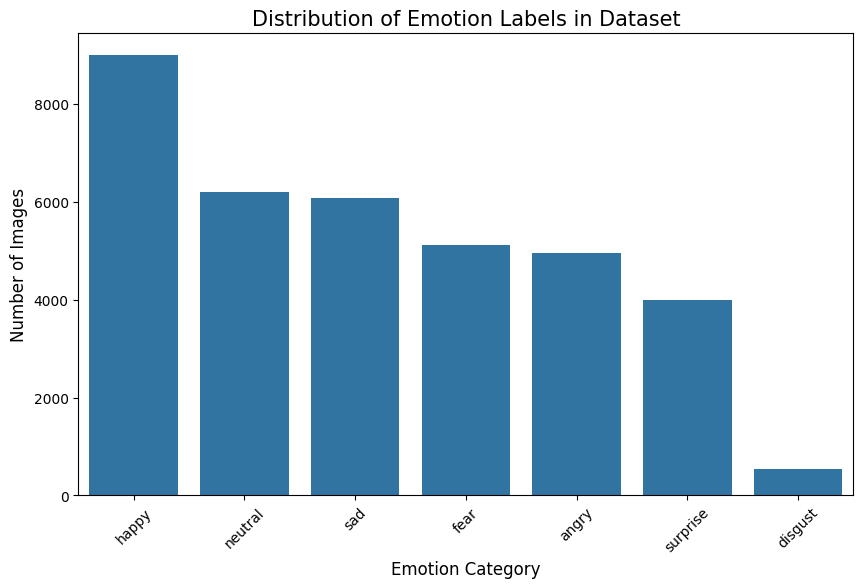

    Emotion  Count
0     happy   8989
1   neutral   6198
2       sad   6077
3      fear   5121
4     angry   4953
5  surprise   4002
6   disgust    547


In [41]:


# calculate counts
label_counts = df_images['label'].value_counts().reset_index()
label_counts.columns = ['Emotion', 'Count']

# plot distribution
plt.figure(figsize=(10, 6))
sns.barplot(data=label_counts, x='Emotion', y='Count')
plt.title('Distribution of Emotion Labels in Dataset', fontsize=15)
plt.xlabel('Emotion Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.show()


print(label_counts)

#Data Augmentation

Data augmentation methods were chosen to keep the face realistic while still adding useful variation. We used small rotations because faces in real photos are often slightly tilted, and horizontal flips are natural because human faces are roughly symmetric left to right. No vertical flips are used because upside-down faces are not realistic in this task. We also used small translations and scaling since faces are not always perfectly centered or captured at the exact same distance. Shear was kept small to reflect slight changes in camera angle without heavily distorting the face. Brightness and contrast adjustments are also realistic because lighting conditions can vary across images. Overall, these augmentations add natural variation that the model may see in real life without changing the emotion itself. Data augmentation can also help with class imbalance by generating more varied training examples for underrepresented classes, which reduces overfitting and gives the model more chances to learn those categories. This is especially useful for smaller classes like disgust, where the limited number of original images may otherwise hurt performance.

In [42]:
data_dir = path

# Adding transforms
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Build file list for augmentation visualization
aug_image_files = []
aug_labels = []
for root, _, files in os.walk(data_dir):
    lbl = os.path.basename(root)
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            aug_image_files.append(os.path.join(root, f))
            aug_labels.append(lbl)

print(f"Found {len(aug_image_files)} images for augmentation visualization")


Found 35887 images for augmentation visualization


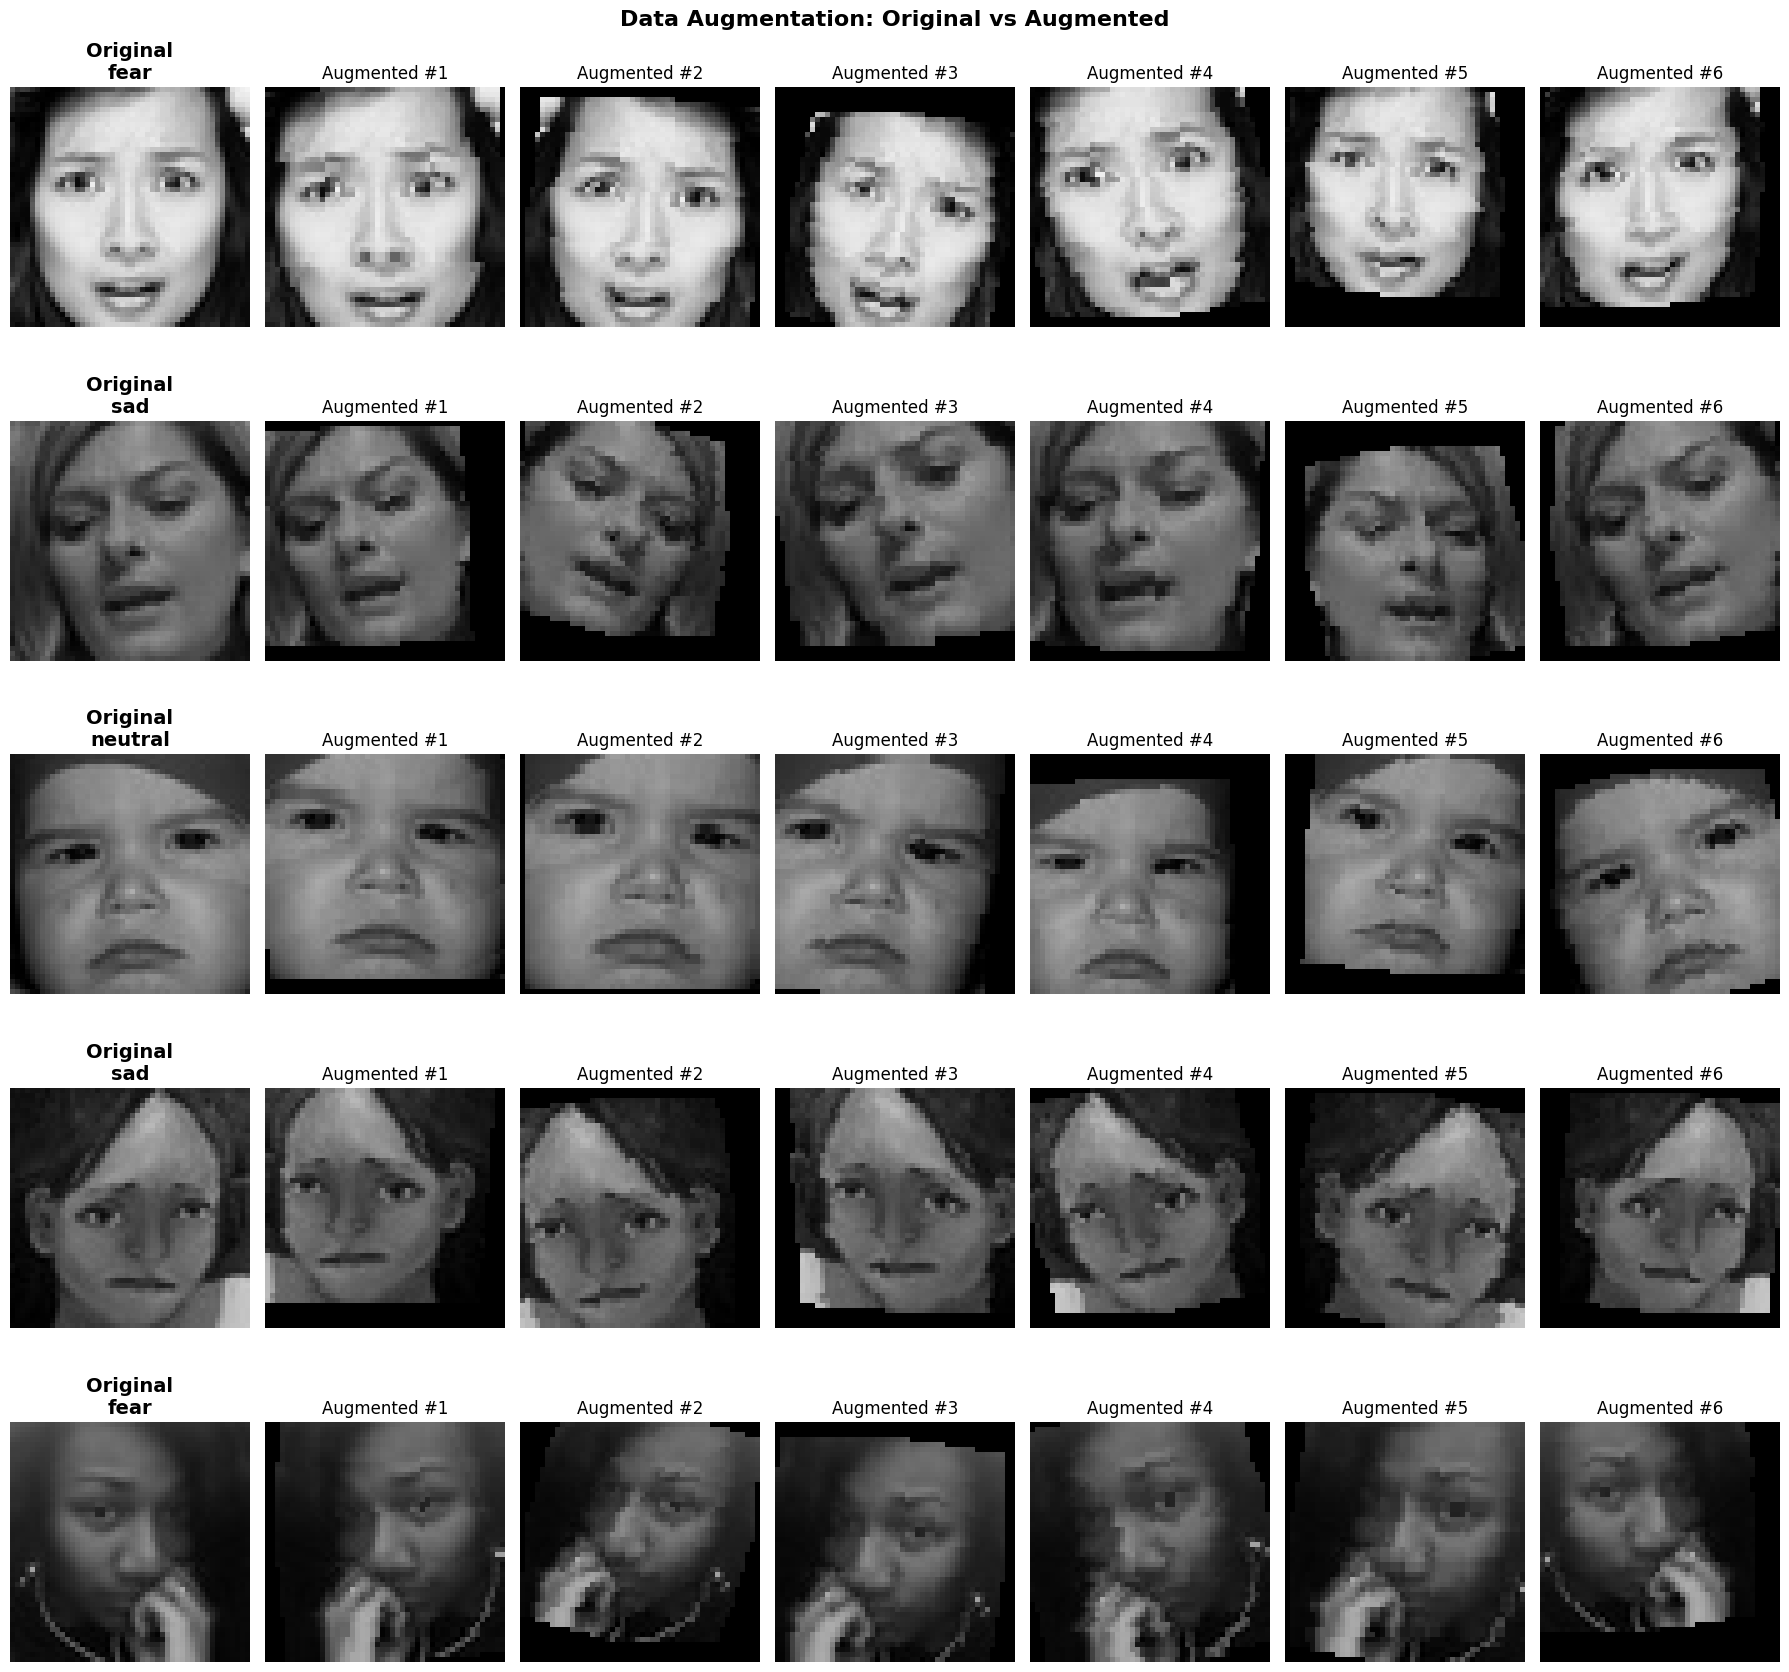

In [43]:
# Visualizing the data augmentation transforms
num_samples = 5
indices = random.sample(range(len(aug_image_files)), num_samples)
sampled_paths = [aug_image_files[i] for i in indices]
sampled_labels = [aug_labels[i] for i in indices]

num_augmentations = 6
fig, axes = plt.subplots(num_samples, num_augmentations + 1, figsize=(18, 3.5 * num_samples))

for i, (img_path, label) in enumerate(zip(sampled_paths, sampled_labels)):
    original_img = Image.open(img_path).convert('L')
    axes[i, 0].imshow(original_img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title('Original\n' + label, fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')

    for j in range(num_augmentations):
        aug_tensor = train_transform(original_img)
        aug_img = aug_tensor.squeeze().numpy()
        aug_img = (aug_img * 0.5) + 0.5
        aug_img = np.clip(aug_img, 0, 1)
        axes[i, j + 1].imshow(aug_img, cmap='gray', vmin=0, vmax=1)
        axes[i, j + 1].set_title(f'Augmented #{j+1}', fontsize=12)
        axes[i, j + 1].axis('off')

plt.suptitle('Data Augmentation: Original vs Augmented', fontsize=16, fontweight='bold')
plt.savefig('vis1.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


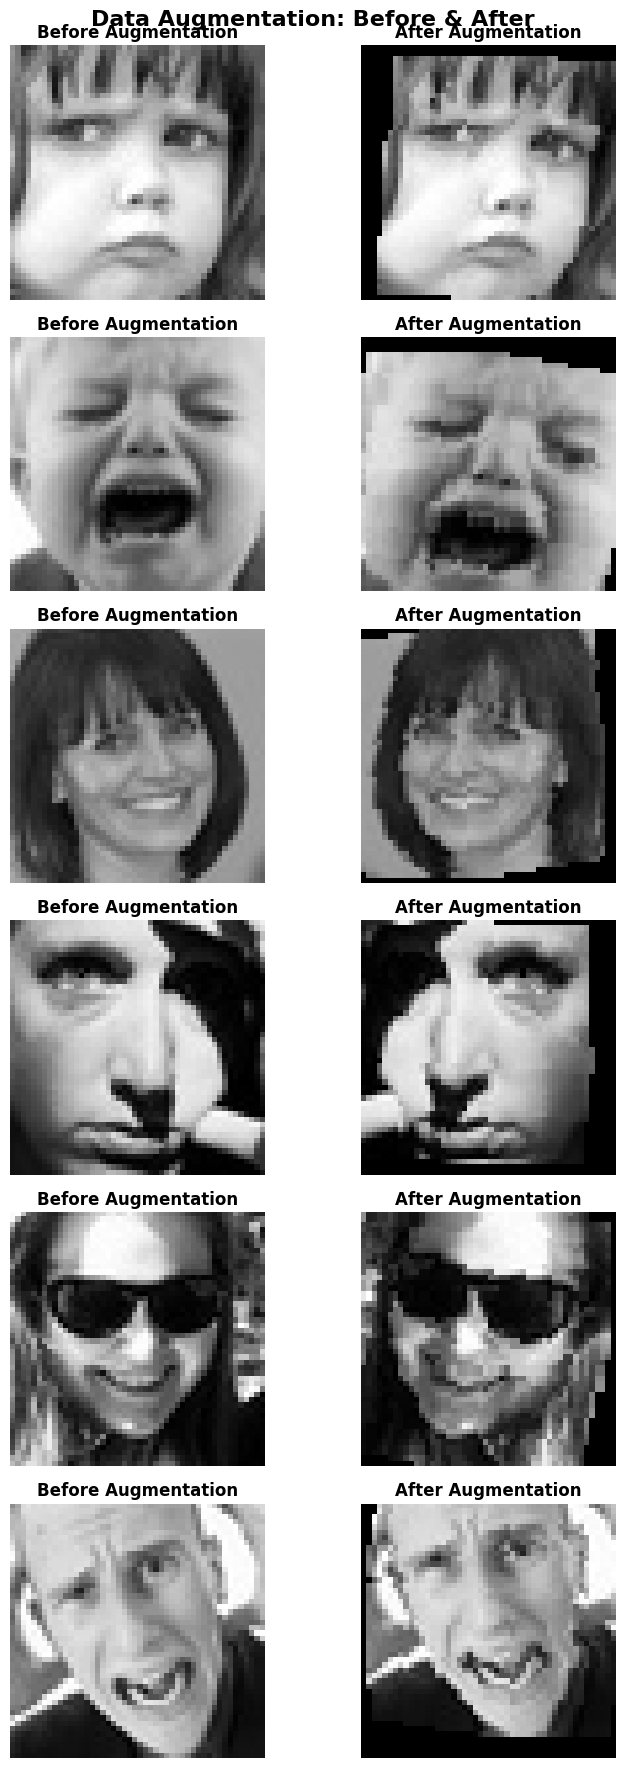

In [44]:
# Before and after image augmentation comparison
num_pairs = 6
indices = random.sample(range(len(aug_image_files)), num_pairs)
sampled_paths = [aug_image_files[i] for i in indices]
sampled_labels = [aug_labels[i] for i in indices]

fig, axes = plt.subplots(num_pairs, 2, figsize=(8, 3 * num_pairs))

for i, (img_path, label) in enumerate(zip(sampled_paths, sampled_labels)):
    original_img = Image.open(img_path).convert('L')

    axes[i, 0].imshow(original_img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title('Before Augmentation', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel(label, fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')

    aug_tensor = train_transform(original_img)
    aug_img = (aug_tensor.squeeze().numpy() * 0.5) + 0.5
    aug_img = np.clip(aug_img, 0, 1)
    axes[i, 1].imshow(aug_img, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title('After Augmentation', fontsize=12, fontweight='bold')
    axes[i, 1].axis('off')

plt.suptitle('Data Augmentation: Before & After', fontsize=16, fontweight='bold')
plt.savefig('vis2.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


#Data Preprocessing

Since some of the data have baby faces, and anime faces and black squares, we tried to filter out the data using CLIP (OpenAI's open-source contrastive learning model). We gave them prompts describing first the adult faces vs. baby faces vs anime faces vs. black squares. However, initial classification found that it was not good at identifying the anime and black squares. It was good at separating the babies vs. adults. We then also classified females vs. males for later experimentation and bias down the line within all the adult faces. We dropped the baby faces for training since it doesn't really align with our vision and goal of this project

In [45]:
data_dir = path

image_files = []
labels_eda_ext = []
for root, _, files in os.walk(data_dir):
    lbl = os.path.basename(root)
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            image_files.append(os.path.join(root, f))
            labels_eda_ext.append(lbl)

print(f"Loaded {len(image_files)} image paths for CLIP filtering")


Loaded 35887 image paths for CLIP filtering


In [46]:
df_images = pd.DataFrame({
    'filepath': image_files,
    'label': labels_eda_ext
})

unique_labels = df_images['label'].unique()

sampled_images_paths = []
for label in unique_labels:
    label_samples = df_images[df_images['label'] == label].sample(n=min(36, len(df_images[df_images['label'] == label])), random_state=42)
    sampled_images_paths.extend(label_samples.to_dict('records'))

print(f"Total unique labels: {len(unique_labels)}")
print(f"Total sampled images: {len(sampled_images_paths)}")


Total unique labels: 7
Total sampled images: 252


In [47]:
model, preprocess = clip.load("ViT-B/32", device=device)

# Define categories for both passes
type_categories = [
     "a grayscale photograph of an adult person's face with realistic skin texture",
    "a grayscale photograph of a baby or young child with round chubby cheeks",
    "a cartoon drawing with bold black outlines and flat shading, not a photograph",
    "a mostly solid black or dark empty image with no clear face visible",
]
type_text = clip.tokenize(type_categories).to(device)

gender_categories = [
    "a photograph of a man",
    "a photograph of a woman",
]
gender_text = clip.tokenize(gender_categories).to(device)

def classify(image_path, text_tokens):
    img = Image.open(image_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits, _ = model(x, text_tokens)
        probs = logits.softmax(-1).cpu().numpy()[0]
    return probs.argmax(), probs.max()

# Run this on a subset to demonstrate
sample_subset = image_files[:200]

# Pass 1: Filter for Adults
print("Running Pass 1 (Type Classification)...")
adult_files_refined = []
for f in tqdm(sample_subset):
    idx, conf = classify(f, type_text)
    if idx == 0:
        adult_files_refined.append(f)

# Pass 2: Classify Gender (on adults only)
print("Running Pass 2 (Gender Classification)...")
male_files = []
female_files = []

for f in tqdm(adult_files_refined):
    idx, conf = classify(f, gender_text)
    if idx == 0:
        male_files.append(f)
    else:
        female_files.append(f)

print(f"\nResults for {len(sample_subset)} samples:")
print(f"Adults Found: {len(adult_files_refined)}")
print(f"  - Male: {len(male_files)}")
print(f"  - Female: {len(female_files)}")

Running Pass 1 (Type Classification)...


100%|██████████| 200/200 [00:01<00:00, 155.66it/s]


Running Pass 2 (Gender Classification)...


100%|██████████| 97/97 [00:00<00:00, 156.10it/s]


Results for 200 samples:
Adults Found: 97
  - Male: 37
  - Female: 60


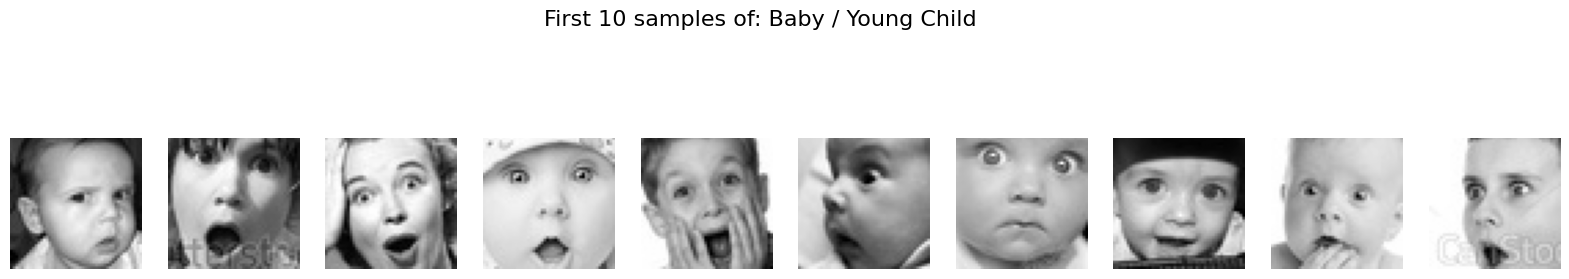

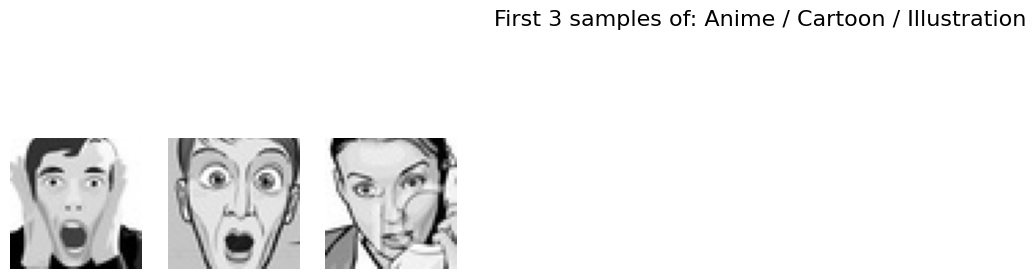

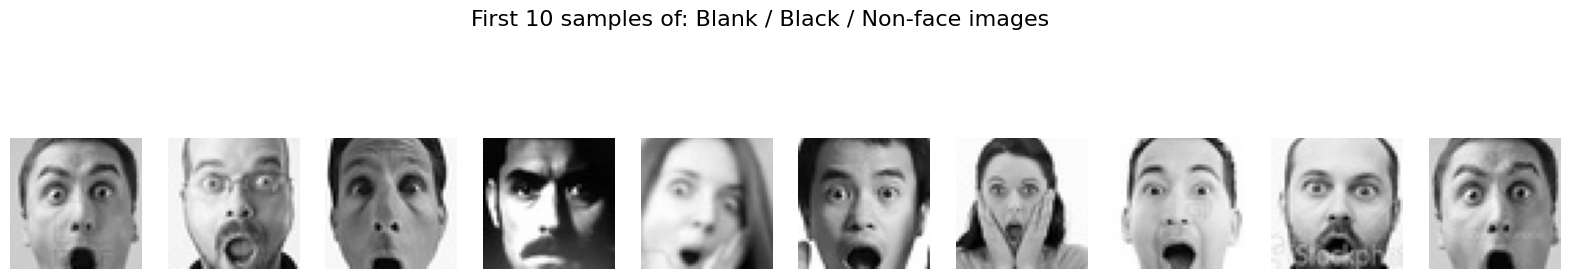

In [48]:
def display_category_samples(category_idx, title, num_samples=10):
    # Reconstruct tags for the subset
    temp_tags = []
    for f in sample_subset:
        idx, conf = classify(f, type_text)
        temp_tags.append(idx)

    indices = [i for i, t in enumerate(temp_tags) if t == category_idx]
    samples = [sample_subset[i] for i in indices[:num_samples]]

    if not samples:
        print(f"No samples found for category: {title}")
        return

    plt.figure(figsize=(20, 4))
    for i, img_path in enumerate(samples):
        plt.subplot(1, num_samples, i + 1)
        img = Image.open(img_path)
        plt.imshow(img, cmap='gray' if 'L' in img.mode else None)
        plt.axis('off')
    plt.suptitle(f"First {len(samples)} samples of: {title}", fontsize=16)
    plt.show()

# Display Baby faces (Index 1)
display_category_samples(1, 'Baby / Young Child')

# Display Anime/Cartoon (Index 2)
display_category_samples(2, 'Anime / Cartoon / Illustration')

# Display Blank/Non-face (Index 3)
display_category_samples(3, 'Blank / Black / Non-face images')

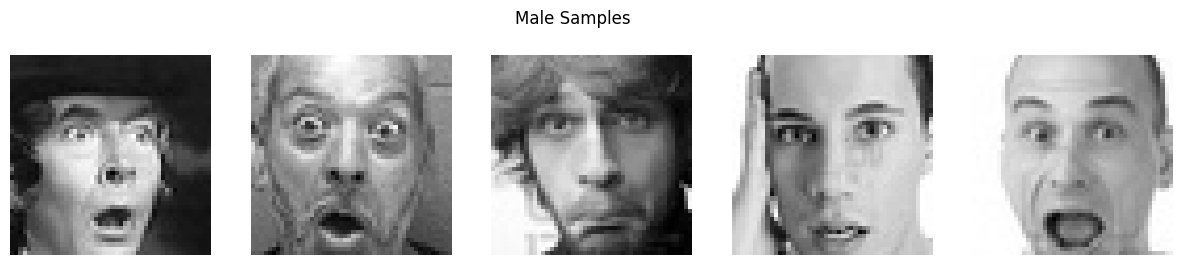

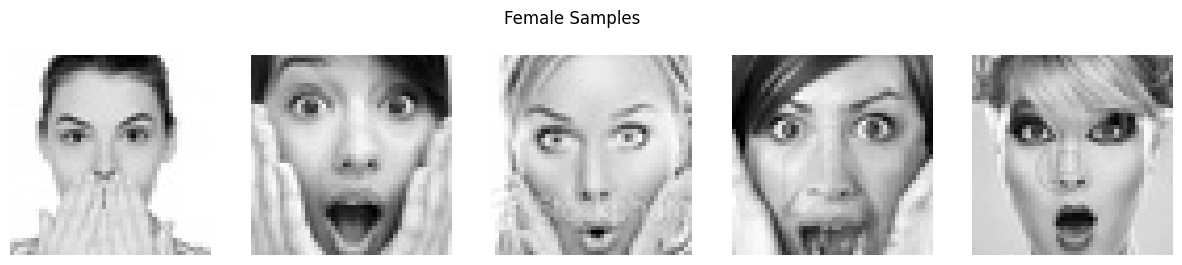

In [49]:
def show_gender_samples(files, title, n=5):
    plt.figure(figsize=(15, 3))
    for i, f in enumerate(files[:n]):
        plt.subplot(1, n, i+1)
        plt.imshow(Image.open(f), cmap="gray")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_gender_samples(male_files, "Male Samples")
show_gender_samples(female_files, "Female Samples")

Full Dataset Run
Above was a run with samples to see how good it is segmenting, and we ran the full code below on the entire dataset.


In [50]:
# Pass 1: Filter for Adults
print(f"Running Pass 1 on {len(image_files)} images...")
adult_full_files_refined = []
baby_full_files_refined = []

for f in tqdm(image_files):
    idx, conf = classify(f, type_text)
    if idx == 0:
        adult_full_files_refined.append(f)
    elif idx == 1:
        baby_full_files_refined.append(f)

# Pass 2: Classify Gender (on adults only)
print(f"Running Pass 2 on {len(adult_full_files_refined)} adults...")
male_full_files = []
female_full_files = []

for f in tqdm(adult_full_files_refined):
    idx, conf = classify(f, gender_text)
    if idx == 0:
        male_full_files.append(f)
    else:
        female_full_files.append(f)

print(f"\nFinal Results for full dataset ({len(image_files)} total images):")
print(f"Adults Found: {len(adult_full_files_refined)}")
print(f"  - Male: {len(male_full_files)}")
print(f"  - Female: {len(female_full_files)}")
print(f"Babies Found: {len(baby_full_files_refined)}")

Running Pass 1 on 35887 images...


100%|██████████| 35887/35887 [03:49<00:00, 156.38it/s]


Running Pass 2 on 25175 adults...


100%|██████████| 25175/25175 [02:44<00:00, 153.46it/s]


Final Results for full dataset (35887 total images):
Adults Found: 25175
  - Male: 11435
  - Female: 13740
Babies Found: 6686


In [56]:
save_dir        = '/content/drive/MyDrive/fer-project/fer2013_processed'
refined_base_dir = '/content/drive/MyDrive/fer-project/fer2013_refined'
os.makedirs(save_dir, exist_ok=True)

export_mapping = {
    'male_adult':   male_full_files,
    'female_adult': female_full_files,
    'baby':         baby_full_files_refined
}

# Copy files to Drive and build adult_records with Drive paths in one pass
adult_records = []

for label, file_list in export_mapping.items():
    label_dir = os.path.join(refined_base_dir, label)
    os.makedirs(label_dir, exist_ok=True)
    print(f"Copying {len(file_list)} files to {label_dir}...")

    for fpath in tqdm(file_list):
        fname       = os.path.basename(fpath)
        parent_name = os.path.basename(os.path.dirname(fpath))  # emotion on Kaggle
        new_fname   = f"{parent_name}_{fname}"                  # e.g. "angry_Training_123.jpg"
        dest_path   = os.path.join(label_dir, new_fname)

        if not os.path.exists(dest_path):
            shutil.copy(fpath, dest_path)

        # Only track adults (not babies)
        if label in ('male_adult', 'female_adult'):
            adult_records.append({
                "drive_path": dest_path,
                "emotion":    parent_name,
                "gender":     "male" if label == "male_adult" else "female"
            })


Copying 11435 files to /content/drive/MyDrive/fer-project/fer2013_refined/male_adult...


100%|██████████| 11435/11435 [00:00<00:00, 20188.55it/s]


Copying 13740 files to /content/drive/MyDrive/fer-project/fer2013_refined/female_adult...


100%|██████████| 13740/13740 [00:00<00:00, 17722.40it/s]


Copying 6686 files to /content/drive/MyDrive/fer-project/fer2013_refined/baby...


100%|██████████| 6686/6686 [00:00<00:00, 18438.84it/s]


In [57]:
# Save JSON once — after copy loop, with Drive paths
data_to_save = {
    "male_full_files":          male_full_files,
    "female_full_files":        female_full_files,
    "adult_full_files_refined": adult_full_files_refined,
    "baby_full_files_refined":  baby_full_files_refined,
    "adult_records":            adult_records   # Drive paths + emotion + gender
}

with open(os.path.join(save_dir, "classified_files.json"), "w") as f:
    json.dump(data_to_save, f)

import pandas as pd
pd.DataFrame(adult_records).to_csv(
    os.path.join(save_dir, "adult_metadata.csv"), index=False
)

print(f"\nLoad this dataset by setting path = '{refined_base_dir}'")
print(f"adult_records saved: {len(adult_records)} entries")


Load this dataset by setting path = '/content/drive/MyDrive/fer-project/fer2013_refined'
adult_records saved: 25175 entries


We then explored the adult-only data by analyzing class distribution for males and females.

In [58]:
# Load directly from JSON — no os.walk, no filename parsing
with open("/content/drive/MyDrive/fer-project/fer2013_processed/classified_files.json") as f:
    loaded_data = json.load(f)

records     = loaded_data["adult_records"]
image_files = [r["drive_path"] for r in records]
labels      = [r["emotion"]    for r in records]
genders     = [r["gender"]     for r in records]

emotion_names  = sorted(set(labels))
emotion_to_idx = {emotion: i for i, emotion in enumerate(emotion_names)}
idx_to_emotion = {i: emotion for emotion, i in emotion_to_idx.items()}

print("Emotion Classes:", emotion_names)
print("Total refined images:", len(image_files))

Emotion Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total refined images: 25175


In [63]:
print(image_files)

['/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PublicTest_78686873.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PrivateTest_27580582.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PublicTest_63291719.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PrivateTest_43252384.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PrivateTest_30329445.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PrivateTest_81281432.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PrivateTest_11501834.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PublicTest_73221398.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PrivateTest_14015382.jpg', '/content/drive/MyDrive/fer-project/fer2013_refined/male_adult/surprise_PrivateTest_30819571.jpg', '/content/dr

In [59]:

# Dictionary to store counts: {gender: {emotion: count}}
emotion_gender_counts = defaultdict(lambda: defaultdict(int))

# Iterate through the collected data to populate counts
for i in range(len(labels)):
    emotion = labels[i]
    gender = genders[i]
    emotion_gender_counts[gender][emotion] += 1

print("Emotion counts by gender:")
for gender_key in sorted(emotion_gender_counts.keys()):
    display_gender = "Men" if gender_key == "male" else "Women"
    print(f"\n{display_gender}:")
    for emotion_key in sorted(emotion_gender_counts[gender_key].keys()):
        count = emotion_gender_counts[gender_key][emotion_key]
        print(f"  - {emotion_key}: {count}")


Emotion counts by gender:

Women:
  - angry: 1297
  - disgust: 227
  - fear: 2180
  - happy: 4414
  - neutral: 1959
  - sad: 2243
  - surprise: 1420

Men:
  - angry: 2358
  - disgust: 239
  - fear: 1548
  - happy: 2235
  - neutral: 2475
  - sad: 1801
  - surprise: 779


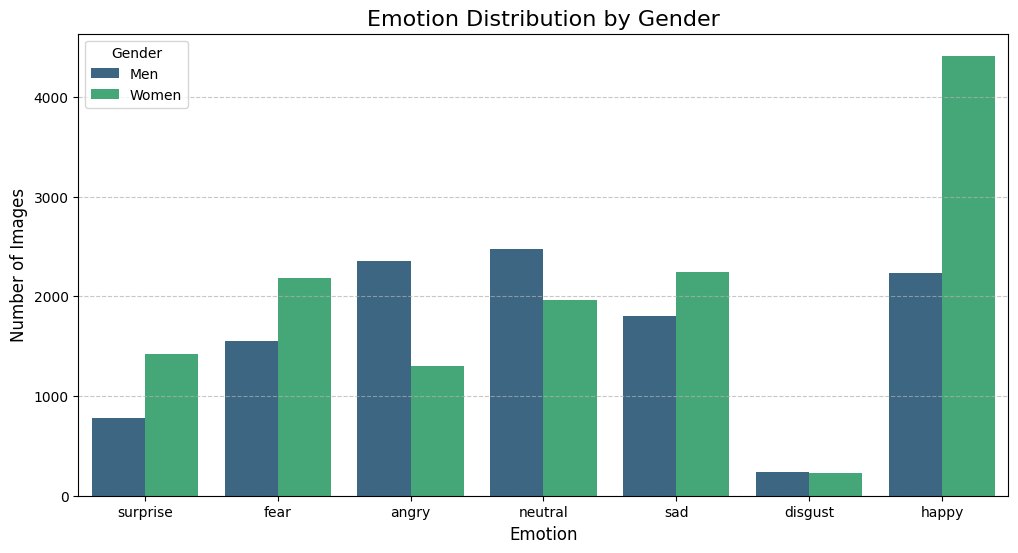

In [60]:
# Prepare data for plotting
plot_data = []
for gender, emotion_counts in emotion_gender_counts.items():
    display_gender = "Men" if gender == "male" else "Women"
    for emotion, count in emotion_counts.items():
        plot_data.append({"Gender": display_gender, "Emotion": emotion, "Count": count})

df_plot = pd.DataFrame(plot_data)

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x="Emotion", y="Count", hue="Gender", palette="viridis")

plt.title("Emotion Distribution by Gender", fontsize=16)
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.legend(title="Gender")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()